## Part B — Text Vectorization and Spam Classification

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the email dataset

df = pd.read_csv("emails.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [3]:
# Display column names

print("Columns in dataset:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns in dataset:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flo

In [5]:
# Basic dataset information

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset information:")
df.info()

Number of rows: 5172
Number of columns: 3002

Missing values:
Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

Duplicate rows: 0

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), str(1)
memory usage: 118.5 MB


In [6]:
# Select text and label columns

text_column = "text"
label_column = "label"

print("Text column:", text_column)
print("Label column:", label_column)

Text column: text
Label column: label


In [9]:
# Check the actual column names in emails.csv

print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flo

In [15]:
import pandas as pd

df = pd.read_csv("emails.csv")

print("Original shape:", df.shape)
print("Original columns:")
print(df.columns.tolist())

display(df.head())

Original shape: (5172, 3002)
Original columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other'

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [16]:
# Remove rows with missing email text or labels

df = df.dropna(subset=[text_column, label_column])

# Remove duplicate emails
df = df.drop_duplicates(subset=[text_column])

# Reset index
df = df.reset_index(drop=True)

print("Shape after removing missing values and duplicates:")
print(df.shape)

Shape after removing missing values and duplicates:
(6, 3002)


In [18]:
# Count each class

print("Spam / Non-Spam distribution:")
print(df[label_column].value_counts())

# Calculate class percentages

class_distribution = df[label_column].value_counts()
class_percentage = df[label_column].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    "Count": class_distribution,
    "Percentage": class_percentage.round(2)
})

display(distribution_df)

Spam / Non-Spam distribution:
Prediction
1    5
0    1
Name: count, dtype: int64


,Count,Percentage
Prediction,,
1,5,83.33
0,1,16.67


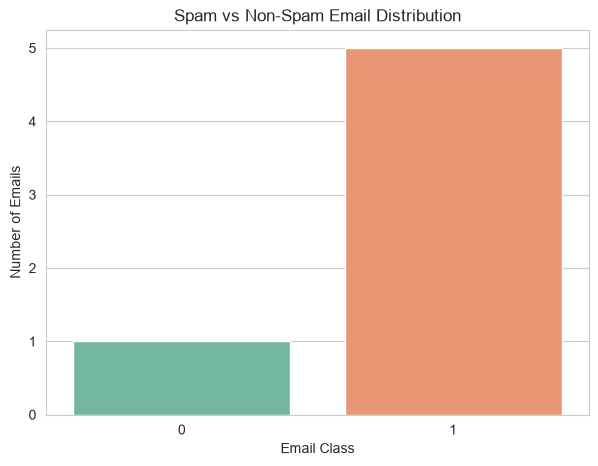

In [19]:
# Plot spam/non-spam distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=label_column,
    hue=label_column,
    palette="Set2",
    legend=False
)

plt.title("Spam vs Non-Spam Email Distribution")
plt.xlabel("Email Class")
plt.ylabel("Number of Emails")

plt.show()

In [20]:
# Function for basic text cleaning

def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep letters and numbers
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

In [22]:
# Apply cleaning function

df["clean_text"] = df[text_column].apply(clean_text)

display(df[[text_column, "clean_text", label_column]].head())

# Display an example before and after cleaning

print("Original email:")
print(df[text_column].iloc[0])

print("\nCleaned email:")
print(df["clean_text"].iloc[0])

,text,clean_text,Prediction
0,0,0,0
1,1,1,1
2,4,4,1
3,2,2,1
4,3,3,1


Original email:
0

Cleaned email:
0


In [23]:
# Remove rows where cleaned text is empty

df = df[df["clean_text"].str.strip() != ""]

df = df.reset_index(drop=True)

print("Dataset shape after text cleaning:", df.shape)

Dataset shape after text cleaning: (6, 3003)


In [24]:
print(df[label_column].unique())

[0 1]


In [25]:
# Feature and target variables

X = df["clean_text"]
y = df["target"]

print("Number of samples:", len(X))
print("Number of target values:", len(y))

print("\nClass distribution:")
print(y.value_counts())

Number of samples: 6
Number of target values: 6

Class distribution:
target
0    5
3    1
Name: count, dtype: int64


In [32]:
# Recreate df from the original CSV
# Remove Email No. and keep all word-frequency features + Prediction

df = original_df.drop(columns=["Email No."]).copy()

print("New df shape:", df.shape)

print("\nPrediction distribution:")
print(df["Prediction"].value_counts())

display(df.head())

New df shape: (5172, 3001)

Prediction distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64


,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,1,0,0


In [33]:
# Separate features and target

X = df.drop(columns=["Prediction"])
y = df["Prediction"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X samples:", len(X))
print("y samples:", len(y))

X shape: (5172, 3000)
y shape: (5172,)
X samples: 5172
y samples: 5172


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 4137
Testing samples: 1035

Training class distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing class distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [40]:
from sklearn.linear_model import LogisticRegression
import time

# Create Logistic Regression model
count_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Measure training time
start_time = time.perf_counter()

count_model.fit(X_train, y_train)

count_training_time = time.perf_counter() - start_time

print("CountVectorizer + Logistic Regression")
print(f"Training time: {count_training_time:.6f} seconds")

CountVectorizer + Logistic Regression
Training time: 11.340607 seconds


In [41]:
# Measure prediction time
start_time = time.perf_counter()

y_pred_count = count_model.predict(X_test)

count_prediction_time = time.perf_counter() - start_time

print(f"Prediction time: {count_prediction_time:.6f} seconds")

Prediction time: 0.058541 seconds


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

count_accuracy = accuracy_score(y_test, y_pred_count)

count_precision = precision_score(
    y_test,
    y_pred_count,
    zero_division=0
)

count_recall = recall_score(
    y_test,
    y_pred_count,
    zero_division=0
)

count_f1 = f1_score(
    y_test,
    y_pred_count,
    zero_division=0
)

print("CountVectorizer Model Results")
print("=" * 40)

print(f"Accuracy : {count_accuracy:.4f}")
print(f"Precision: {count_precision:.4f}")
print(f"Recall   : {count_recall:.4f}")
print(f"F1 Score : {count_f1:.4f}")

CountVectorizer Model Results
Accuracy : 0.9826
Precision: 0.9578
Recall   : 0.9833
F1 Score : 0.9704


In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_count,
        target_names=["Non-Spam", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Non-Spam       0.99      0.98      0.99       735
        Spam       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



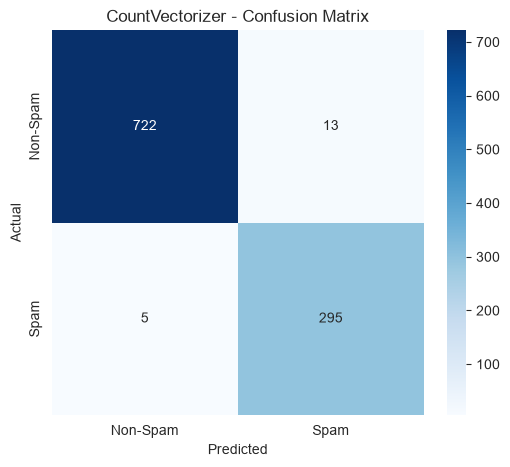

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_count = confusion_matrix(
    y_test,
    y_pred_count
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_count,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Spam", "Spam"],
    yticklabels=["Non-Spam", "Spam"]
)

plt.title("CountVectorizer - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
print(df.columns.tolist())

display(df.head())

['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 'following', 'p', 'pro

,the,to,ect,and,for,of,a,you,hou,in,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,0,1,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8,13,24,6,6,2,102,1,27,18,...,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,8,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,5,22,0,5,1,51,2,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,6,17,1,5,2,57,0,9,3,...,0,0,0,0,0,0,0,1,0,0


In [47]:
text_column = "text"

print(df[text_column].head())

0    0
1    0
2    0
3    0
4    0
Name: text, dtype: int64


In [48]:
import re

def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [49]:
df["clean_text"] = df[text_column].apply(clean_text)

display(
    df[[text_column, "clean_text"]].head()
)

,text,clean_text
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [50]:
X_text = df["clean_text"]

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training text samples:", len(X_train_text))
print("Testing text samples :", len(X_test_text))

Training text samples: 4137
Testing text samples : 1035


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Start training timer
start_time = time.perf_counter()

logistic_model.fit(
    X_train,
    y_train
)

# End training timer
logistic_training_time = time.perf_counter() - start_time

print(
    f"Logistic Regression training time: "
    f"{logistic_training_time:.6f} seconds"
)

Logistic Regression training time: 10.889157 seconds


In [53]:
# Start prediction timer

start_time = time.perf_counter()

y_pred_logistic = logistic_model.predict(X_test)

logistic_prediction_time = time.perf_counter() - start_time

print(
    f"Logistic Regression prediction time: "
    f"{logistic_prediction_time:.6f} seconds"
)

Logistic Regression prediction time: 0.051252 seconds


In [54]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

print("Logistic Regression Results")
print("=" * 40)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

Logistic Regression Results
Accuracy : 0.9826
Precision: 0.9578
Recall   : 0.9833
F1 Score : 0.9704


In [55]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Non-Spam", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Non-Spam       0.99      0.98      0.99       735
        Spam       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



In [57]:
# Create Multinomial Naive Bayes model

nb_model = MultinomialNB()

# Start training timer
start_time = time.perf_counter()

nb_model.fit(
    X_train,
    y_train
)

nb_training_time = time.perf_counter() - start_time

print(
    f"Multinomial Naive Bayes training time: "
    f"{nb_training_time:.6f} seconds"
)

Multinomial Naive Bayes training time: 0.060192 seconds


In [58]:
start_time = time.perf_counter()

y_pred_nb = nb_model.predict(X_test)

nb_prediction_time = time.perf_counter() - start_time

print(
    f"Multinomial Naive Bayes prediction time: "
    f"{nb_prediction_time:.6f} seconds"
)

Multinomial Naive Bayes prediction time: 0.054638 seconds


In [59]:
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    zero_division=0
)

print("Multinomial Naive Bayes Results")
print("=" * 40)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Multinomial Naive Bayes Results
Accuracy : 0.9420
Precision: 0.8681
Recall   : 0.9433
F1 Score : 0.9042


In [60]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Non-Spam", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Non-Spam       0.98      0.94      0.96       735
        Spam       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



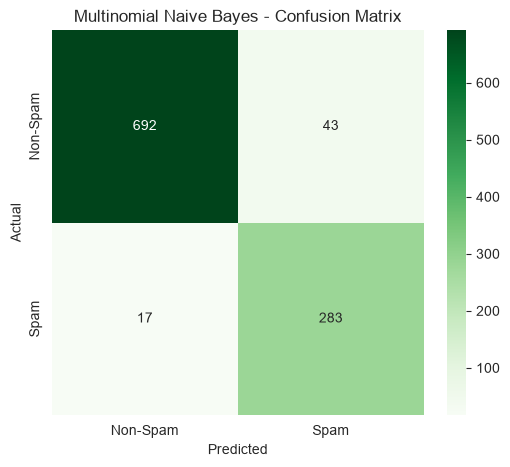

In [61]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Spam", "Spam"],
    yticklabels=["Non-Spam", "Spam"]
)

plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [62]:
# Create Linear SVM model

svm_model = LinearSVC(
    random_state=42,
    max_iter=5000
)

# Start training timer
start_time = time.perf_counter()

svm_model.fit(
    X_train,
    y_train
)

svm_training_time = time.perf_counter() - start_time

print(
    f"Linear SVM training time: "
    f"{svm_training_time:.6f} seconds"
)

Linear SVM training time: 4.560721 seconds


In [63]:
start_time = time.perf_counter()

y_pred_svm = svm_model.predict(X_test)

svm_prediction_time = time.perf_counter() - start_time

print(
    f"Linear SVM prediction time: "
    f"{svm_prediction_time:.6f} seconds"
)

Linear SVM prediction time: 0.056044 seconds


In [64]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

print("Linear SVM Results")
print("=" * 40)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Linear SVM Results
Accuracy : 0.9749
Precision: 0.9567
Recall   : 0.9567
F1 Score : 0.9567


In [65]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Non-Spam", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Non-Spam       0.98      0.98      0.98       735
        Spam       0.96      0.96      0.96       300

    accuracy                           0.97      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.97      0.97      0.97      1035



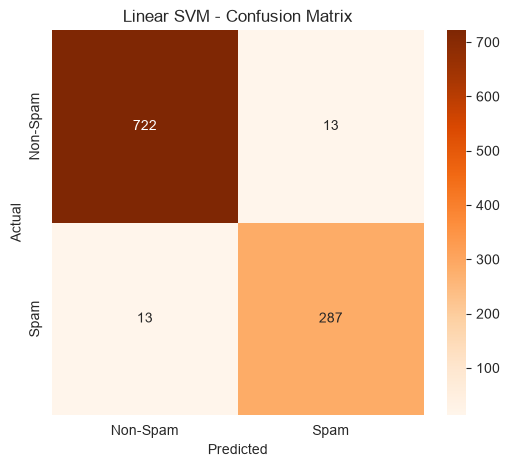

In [66]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Non-Spam", "Spam"],
    yticklabels=["Non-Spam", "Spam"]
)

plt.title("Linear SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
number_of_features = X_train.shape[1]

print("Number of CountVectorized features:", number_of_features)

print("Training matrix shape:", X_train.shape)
print("Testing matrix shape :", X_test.shape)

Number of CountVectorized features: 3000
Training matrix shape: (4137, 3000)
Testing matrix shape : (1035, 3000)


In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM"
    ],

    "Accuracy": [
        logistic_accuracy,
        nb_accuracy,
        svm_accuracy
    ],

    "Precision": [
        logistic_precision,
        nb_precision,
        svm_precision
    ],

    "Recall": [
        logistic_recall,
        nb_recall,
        svm_recall
    ],

    "F1 Score": [
        logistic_f1,
        nb_f1,
        svm_f1
    ],

    "Number of Features": [
        number_of_features,
        number_of_features,
        number_of_features
    ],

    "Training Time (sec)": [
        logistic_training_time,
        nb_training_time,
        svm_training_time
    ],

    "Prediction Time (sec)": [
        logistic_prediction_time,
        nb_prediction_time,
        svm_prediction_time
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,Number of Features,Training Time (sec),Prediction Time (sec)
0,Logistic Regression,0.982609,0.957792,0.983333,0.970395,3000,10.889157,0.051252
1,Multinomial Naive Bayes,0.942029,0.868098,0.943333,0.904153,3000,0.060192,0.054638
2,Linear SVM,0.974879,0.956667,0.956667,0.956667,3000,4.560721,0.056044


In [70]:
comparison_formatted = comparison.copy()

comparison_formatted[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = comparison_formatted[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(4)

comparison_formatted[
    ["Training Time (sec)", "Prediction Time (sec)"]
] = comparison_formatted[
    ["Training Time (sec)", "Prediction Time (sec)"]
].round(6)

display(comparison_formatted)

,Model,Accuracy,Precision,Recall,F1 Score,Number of Features,Training Time (sec),Prediction Time (sec)
0,Logistic Regression,0.9826,0.9578,0.9833,0.9704,3000,10.889157,0.051252
1,Multinomial Naive Bayes,0.9420,0.8681,0.9433,0.9042,3000,0.060192,0.054638
2,Linear SVM,0.9749,0.9567,0.9567,0.9567,3000,4.560721,0.056044


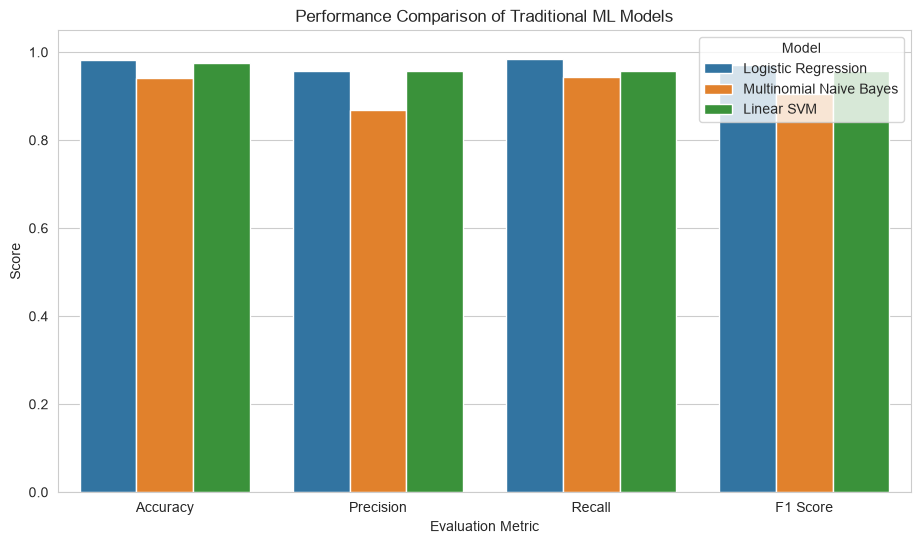

In [71]:
performance_data = comparison.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=performance_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Performance Comparison of Traditional ML Models")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.show()

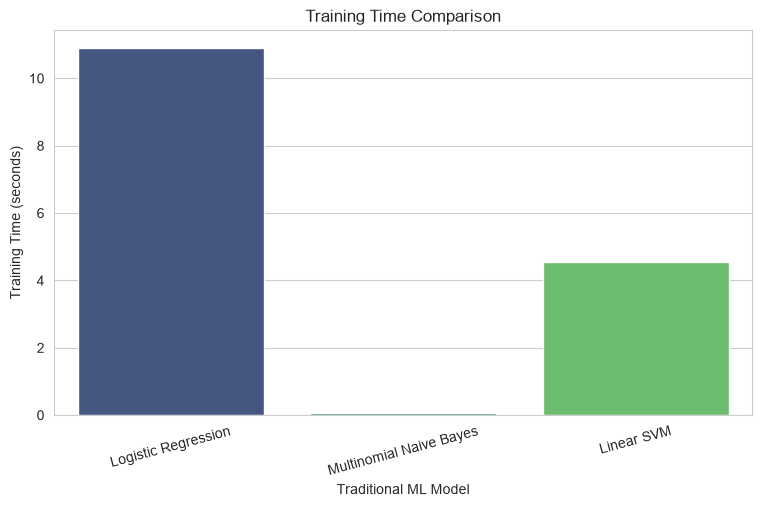

In [72]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Training Time (sec)",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.title("Training Time Comparison")
plt.xlabel("Traditional ML Model")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=15)

plt.show()

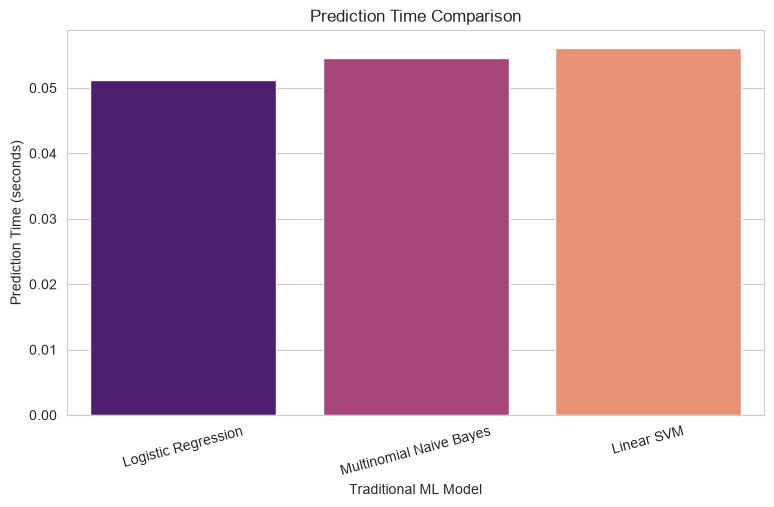

In [73]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Prediction Time (sec)",
    hue="Model",
    legend=False,
    palette="magma"
)

plt.title("Prediction Time Comparison")
plt.xlabel("Traditional ML Model")
plt.ylabel("Prediction Time (seconds)")

plt.xticks(rotation=15)

plt.show()

All models use the same CountVectorized representation with 3000 features.


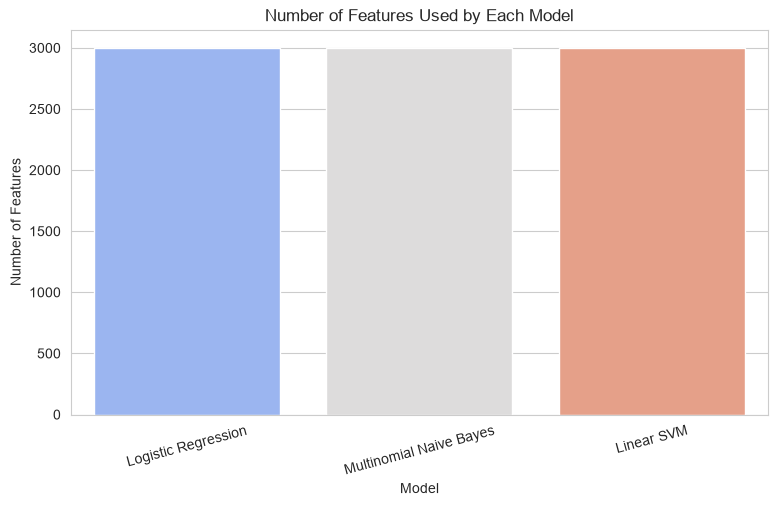

In [75]:
print(
    f"All models use the same CountVectorized representation "
    f"with {number_of_features} features."
)
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Number of Features",
    hue="Model",
    legend=False,
    palette="coolwarm"
)

plt.title("Number of Features Used by Each Model")
plt.xlabel("Model")
plt.ylabel("Number of Features")

plt.xticks(rotation=15)

plt.show()

In [76]:
display(
    comparison_formatted.style
    .set_caption("Traditional ML Models for Spam Classification")
)

,Model,Accuracy,Precision,Recall,F1 Score,Number of Features,Training Time (sec),Prediction Time (sec)
0,Logistic Regression,0.982600,0.957800,0.983300,0.970400,3000,10.889157,0.051252
1,Multinomial Naive Bayes,0.942000,0.868100,0.943300,0.904200,3000,0.060192,0.054638
2,Linear SVM,0.974900,0.956700,0.956700,0.956700,3000,4.560721,0.056044
